# Цено-Временная Регрессия

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import datetime
import heapq
import math
from sklearn import linear_model
import time
import seaborn as sea
import matplotlib
def MODULE_1():
    conn = sqlite3.connect("Main_base.db") #LastDateBase22
    cursor = conn.cursor()

    id_word = "ID_Картины"
    id_author_word = "ID_Автора"
    now_type = float# str
    #def LinModelTrainer(n):






    def V2(ID_paint,word,word2,df,uniq_id,sort_df,df_copy,date):
        #Тут мы делаем угловой коэф и из него "прогнозный метод".

        x1 = sort_df[sort_df[id_word]==ID_paint][word].iloc[-1]
        y1 = sort_df[sort_df[id_word]==ID_paint][word2].iloc[-1]

        x2 = sort_df[sort_df[id_word]==ID_paint][word].iloc[-2]
        y2 = sort_df[sort_df[id_word]==ID_paint][word2].iloc[-2]



        dx=x1-x2
        dy=y1-y2
        k=dy/dx

        d=time.mktime(date.timetuple())
        return y1+(d-x1)*k

    def V3(ID_paint,word,word2,df,uniq_id,sort_df,df_copy,date):
        today = time.mktime(date.timetuple())
        paint = sort_df[sort_df[id_word]==ID_paint]
        lens = len(paint.values)
        n = 2 # число по которым все картины разбиваются на тренировочный стек
        param1=0
        param2=lens
        xxx=[]
        x_train, y_train = [],[]

        for i in range(param1,param2):
            x_train.append([paint.iloc[-i][word]])
            y_train.append([paint.iloc[-i][word2]])
        print(x_train)
        print(y_train)
        model = linear_model.LinearRegression().fit(x_train,y_train)
        x_train.append([today])
        res = model.predict(x_train)
        return [x_train,res]





    #def V2()
    #Изменятеся ли Date при переприсваивании  переменной?
    #



    def MainTrainer(ID_paint,n,df_,word,word2,date_=datetime.datetime.now()):
        print("\n ВЫБЕРИТЕ КАРТИНУ ИЗ БАЗЫ ДАННЫХ \n")
        print(df_[[id_word,word,word2]])
        print("Для выхода введите '-1'")
        flag =0
        while(ID_paint!="-1"):

            answer = input("Дата прогноза: ")
            if answer != "":
                answer = answer.split(".")
                date = datetime.date(int(answer[2]),int(answer[1]),int(answer[0]))
            else:
                 date=date_

            #sea.lineplot(data=flights_data, x="year", y="passengers")
            df = df_.copy(deep=True)

            df = df_.copy(deep=True)
            df_copy = df.copy(deep=True)
            ID_paint = now_type (input("ID Картины : "))
            df_copy = df.copy(deep=True)
            print("\nИНФОРМАЦИЯ О ДАТЕ/ЦЕНАХ НА ДАННУЮ КАРТИНУ\n")
            result_y=df_copy[df_copy[id_word]==ID_paint] 
            print(result_y[[id_word,word,word2]])

            #Вытягиваем ТЕКСТ_ДАТЫ из БД и переделываем в Datetime -> UNIX.
            for i in df[word]:
                c = i.split("-")
                c = datetime.date(int(c[0]),int(c[1]),int(c[2]))
                c=time.mktime(c.timetuple())
                df = df.replace(i,c)
            #ПОДГОТАВЛИВАЕМ ШАБЛОНЫ ДЛЯ ТРЕНИРОВКИ ЛИНЕЙНОЙ РЕГРЕССИИИ
            x_train,y_train = df[df[id_author_word]==-1][[word,id_word]],df[df[id_author_word]==-1][[word,id_word]]
            # СОРТИРУЕМ БАЗУ ДАННЫХ ПО ДАТЕ(ВОТ ЗАЧЕМ UNIX).
            sort_df = df.sort_values(by = word)
            #Это требуется для возвращения от Unix к Date-формату
            df_visual = df_copy[df_copy[id_word]==ID_paint]
            df_visual = df_visual[[word,word2]]
            #sort_df_visual[word] = pd.to_datetime(df[word], unit='m')
            print("\n Изменение цен на картину")

            sea.set_style("darkgrid")
            df_visual[word] = pd.to_datetime(df_visual[word], format="%Y/%m/%d")
            sea.lineplot(data=df_visual, x=word, y=word2)
            matplotlib.pyplot.show()


            uniq_id=df[id_word].unique()

            uniq_id[0],uniq_id[1]=uniq_id[1],uniq_id[0]

            uniq_id=(sorted(uniq_id))


            x_train=[]
            y_train=[]
            if flag==0:
                k=0.1

                res = V3(ID_paint,word,word2,df,uniq_id,sort_df,df_copy,date)
                result2X = res[0]
                result2Y = res[1]
                try:
                    result3 = V2(ID_paint,word,word2,df,uniq_id,sort_df,df_copy,date)
                except IndexError:
                    result3=0
                sea.set(rc={'figure.figsize':(7,7)})
                X,Y = [],[]

                for i in range(len(result2X)):
                    X.append(result2X[i][0])
                    Y.append(result2Y[i][0])
                XY = pd.DataFrame([X,Y]).T
                XY.rename(columns={0:word}, inplace=True)
                XY.rename(columns={1:word2}, inplace=True)
                XY[word] = pd.to_datetime(XY[word], unit='s')

                sea.lineplot(data=XY, x=word, y=word2)


                print("\n ДОВЕРИТЕЛЬНЫЕ ПОКАЗАТЕЛИ.\n")
                df = df_visual.copy(deep=True)
                df[word] = pd.to_datetime(df[word], format="%Y/%m/%d")      
                sea.lineplot(data=df, x=word, y=word2,color = "blue")
                print(f"ПО ЛИНЕЙНОЙ РЕГРЕССИИ : {XY[word2].values[-1]}" )


                if result3>0:
                    print(f'На {date} по ПРОГНОЗНОМУ методу картина имеет стоимость {result3}')
                    df = df_visual.copy(deep="True")
                    new = {word:str(date),word2:result3}
                    df=df.append(new,ignore_index=True)
                    df[word] = pd.to_datetime(df[word], format="%Y/%m/%d")
                    sea.lineplot(data=df[-2:], x=word, y=word2,color = "green")
                matplotlib.pyplot.show()
                input("Введите любую клавишу чтобы начать анализ сначала: ")
                print("\n\n")








    def Analize(Table,ID_paint):
        df = pd.read_sql(f"SELECT * FROM {Table}", conn)
        if Table == "Offer":
            word = "Дата_продажи"
            word2 = "Цена_продажи"
        elif Table == "Demand":
            word = "Дата_предложения"
            word2 = "Цена_предложения"
        elif Table == "Supply":
            word = "Дата_спроса"
            word2= "Цена_спроса"

        df = df[[word,word2,id_word,id_author_word]]
        df = df.dropna()
        MainTrainer(ID_paint,2,df,word,word2)


    while(True):      
        print("Что спрогнозировать на сегодняшний день?")
        f = 1
        while(f):
            ans=input("Спрос - 1, Предложение - 2, Продажа - 3: ")
            if ans == "1":
                Analize("Supply",'1')
                f=0
            elif ans == '2':
                Analize("Demand",'1')
                f=0
            elif ans =='3':
                Analize("Offer",'1')
                f=0
            else:
                print("Ошибка ввода!")
                

Что спрогнозировать на сегодняшний день?
Спрос - 1, Предложение - 2, Продажа - 3: 3

 ВЫБЕРИТЕ КАРТИНУ ИЗ БАЗЫ ДАННЫХ 

    ID_Картины Дата_продажи  Цена_продажи
37         2.0   2012-01-25        1000.0
38         3.0   1999-08-05         150.0
39         4.0   2005-01-12         350.0
40         5.0   2011-11-21        5643.0
41         6.0   2019-07-07         321.0
42         7.0   2021-03-03         512.0
43         8.0   2005-12-11         213.0
45        10.0   2009-05-05         765.0
47        12.0   2012-01-25         150.0
48        13.0   1999-08-05         550.0
49        14.0   2005-01-12         999.0
50        15.0   2011-11-21         123.0
51        16.0   2019-07-07       32154.0
52        17.0   2021-03-03         543.0
53        18.0   2005-12-11          43.0
55        20.0   2009-05-05         312.0
57        22.0   2012-01-25        2213.0
58        23.0   1999-08-05         321.0
59        24.0   2005-01-12         321.0
60        25.0   2011-11-21         312.

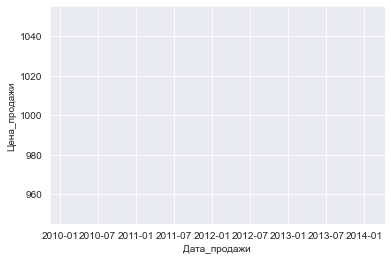

[[1327438800.0]]
[[1000.0]]

 ДОВЕРИТЕЛЬНЫЕ ПОКАЗАТЕЛИ.

ПО ЛИНЕЙНОЙ РЕГРЕССИИ : 1000.0


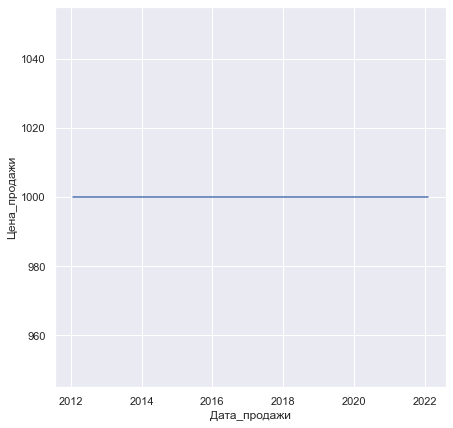

In [ ]:
MODULE_1()